## TASK 1

PCA / Randomized PCA / Logistic Regression

##Imports + Reproducibility

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import check_random_state
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import random
import itertools
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras import backend as Kb

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

2025-12-07 23:11:43.448575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-07 23:11:51.122789: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-07 23:12:00.164171: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


##Load CIFAR-10, convert to grayscale, flatten

In [ ]:
# Load dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
X = np.concatenate([X_train_full, X_test_full], axis=0)
y = np.concatenate([y_train_full, y_test_full], axis=0).ravel()

# Convert to grayscale
X_gray = (0.2989 * X[...,0] + 0.5870 * X[...,1] + 0.1140 * X[...,2]) / 255.0
n_samples, H, W = X_gray.shape
input_dim = H * W

# Flatten
X_flat = X_gray.reshape(n_samples, input_dim)
print("Dataset shapes:", X_flat.shape, y.shape)


Dataset shapes: (60000, 1024) (60000,)


##Stratified train/test split + Standardization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Mean =", X_train_scaled.mean(), ", Std =", X_train_scaled.std())


Train: (42000, 1024) Test: (18000, 1024)
Mean = -1.3380830834887006e-15 , Std = 1.0000000000000007


##Standard PCA (95% energy)

In [ ]:
pca_std = PCA(n_components=0.95, svd_solver='full', random_state=RANDOM_STATE)
X_train_pca = pca_std.fit_transform(X_train_scaled)
X_test_pca = pca_std.transform(X_test_scaled)
K = pca_std.n_components_

print("K =", K)


K = 163


##Randomized PCA using same K

In [ ]:
pca_rand = PCA(n_components=K, svd_solver='randomized', random_state=RANDOM_STATE)
X_train_pca_rand = pca_rand.fit_transform(X_train_scaled)
X_test_pca_rand = pca_rand.transform(X_test_scaled)

##Helper: Logistic Regression + ROC curves

In [ ]:
def run_pca_lr_and_roc(X_tr_pca, X_te_pca, y_tr, y_te, title_suffix):
    clf = LogisticRegression(max_iter=2000, multi_class='ovr', solver='lbfgs', n_jobs=-1)
    clf.fit(X_tr_pca, y_tr)

    acc = accuracy_score(y_te, clf.predict(X_te_pca))
    print(f"Test Accuracy ({title_suffix}): {acc:.4f}")

    y_score = clf.predict_proba(X_te_pca)
    lb = LabelBinarizer()
    y_te_bin = lb.fit_transform(y_te)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_te_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    micro_auc = roc_auc_score(y_te_bin, y_score, average='micro')
    macro_auc = roc_auc_score(y_te_bin, y_score, average='macro')

    print(f"Macro AUC = {macro_auc:.4f}, Micro AUC = {micro_auc:.4f}")

    plt.figure(figsize=(10,8))
    for i in range(10):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"ROC Curves {title_suffix}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {"acc": acc, "macro_auc": macro_auc, "micro_auc": micro_auc, "per_class_auc": roc_auc}


##Run LR+ROC for Standard PCA & Randomized PCA

/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy (Standard PCA): 0.3023
Macro AUC = 0.7223, Micro AUC = 0.7283


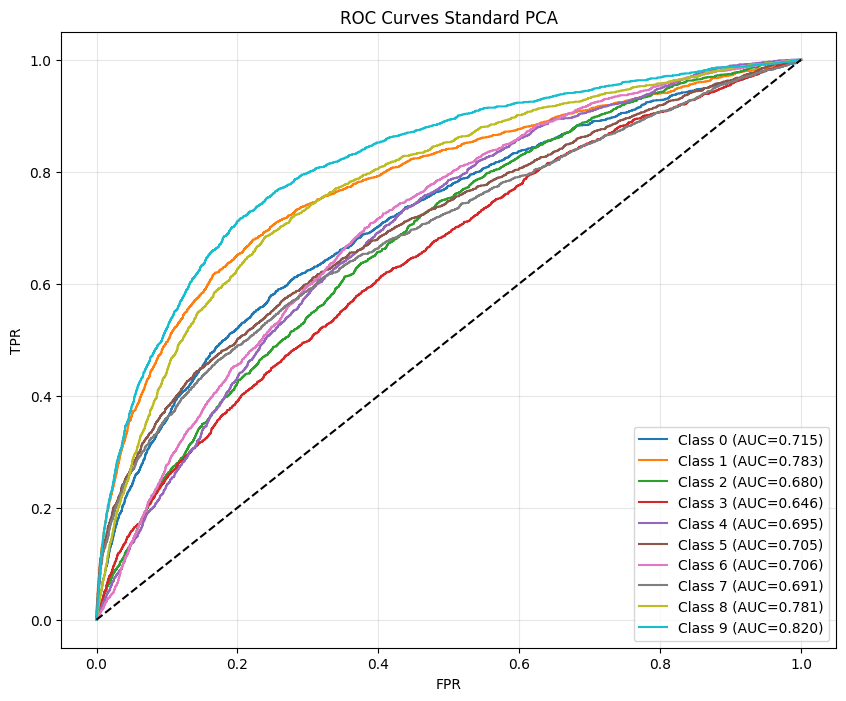

/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy (Randomized PCA): 0.3013
Macro AUC = 0.7221, Micro AUC = 0.7281


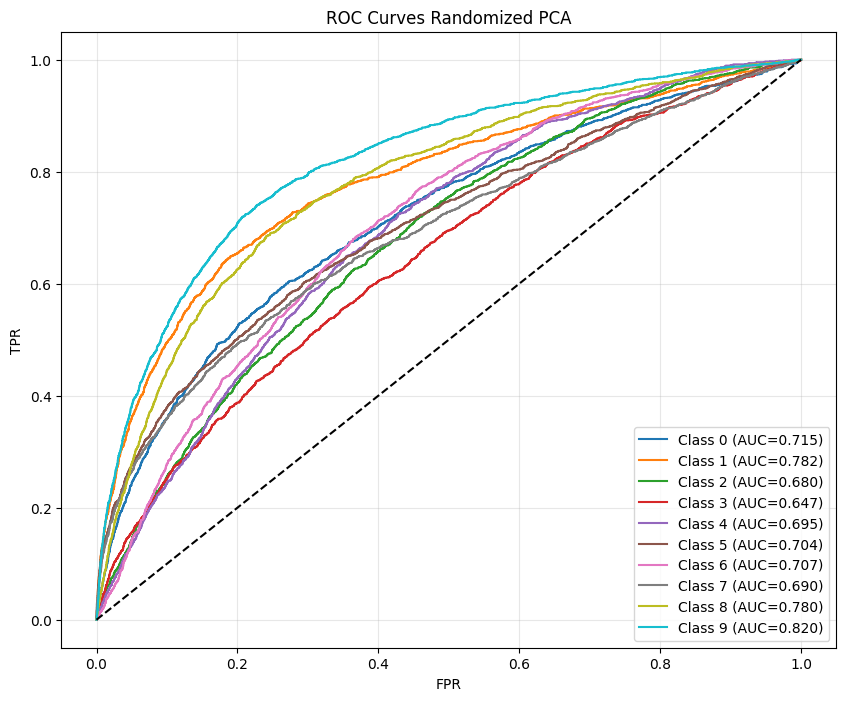

In [ ]:
std_results = run_pca_lr_and_roc(X_train_pca, X_test_pca, y_train, y_test, "Standard PCA")
rnd_results = run_pca_lr_and_roc(X_train_pca_rand, X_test_pca_rand, y_train, y_test, "Randomized PCA")


##Bar plot comparing per-class AUC

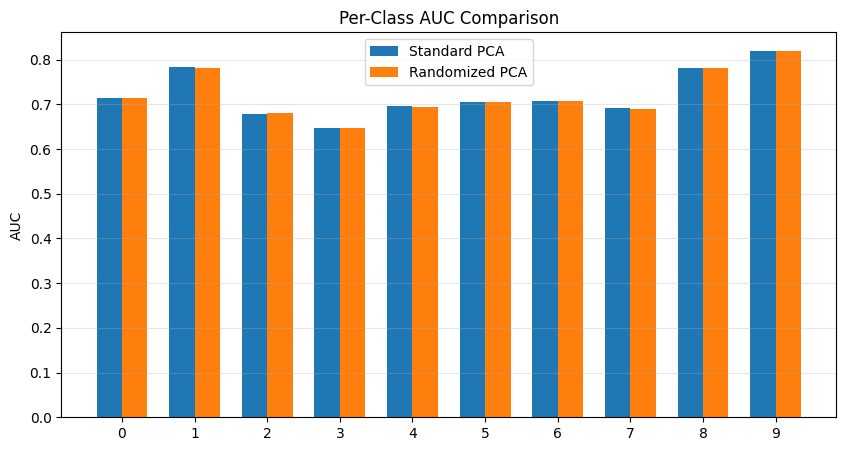

In [ ]:
classes = np.arange(10)
std_auc = [std_results['per_class_auc'][i] for i in classes]
rnd_auc = [rnd_results['per_class_auc'][i] for i in classes]

x = np.arange(10)
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(x-width/2, std_auc, width, label="Standard PCA")
plt.bar(x+width/2, rnd_auc, width, label="Randomized PCA")
plt.xticks(x, classes)
plt.ylabel("AUC")
plt.title("Per-Class AUC Comparison")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## TASK 2

Linear Autoencoder with Tied Weights

##Autoencoder Architecture (Tied Weights)

In [ ]:
from tensorflow.keras import layers, models, constraints, callbacks

latent_dim = K

class TiedDense(layers.Layer):
    def __init__(self, tied_to, activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.tied_to = tied_to
        self.use_bias = use_bias
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        kernel = self.tied_to.kernel
        input_dim = int(kernel.shape[0])
        if self.use_bias:
            self.bias = self.add_weight(shape=(input_dim,), initializer='zeros')
        super().build(input_shape)

    def call(self, inputs):
        kernel = tf.transpose(self.tied_to.kernel)
        out = tf.matmul(inputs, kernel)
        if self.use_bias:
            out = out + self.bias
        return self.activation(out) if self.activation else out


##Build and Train Autoencoder

In [ ]:
input_img = layers.Input(shape=(input_dim,))
encoder = layers.Dense(
    latent_dim, activation='linear', use_bias=False,
    kernel_constraint=constraints.UnitNorm(axis=0),
    name='encoder'
)
encoded = encoder(input_img)
decoded = TiedDense(tied_to=encoder, activation=None)(encoded)
autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
autoencoder.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    validation_data=(X_test_scaled, X_test_scaled),
    epochs=200, batch_size=512, shuffle=True,
    callbacks=[es], verbose=2
)


I0000 00:00:1765129356.736851    4240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13656 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Dense)                 │ (None, 163)            │       166,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tied_dense (TiedDense)          │ (None, 1024)           │       167,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,936 (656.00 KB)

 Trainable params: 167,936 (656.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


2025-12-07 23:12:40.167974: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fab400053c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-07 23:12:40.168002: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-12-07 23:12:40.184456: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-07 23:12:40.321050: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1765129361.725388    4329 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/83 - 4s - 46ms/step - loss: 0.2917 - val_loss: 0.1558
Epoch 2/200
83/83 - 0s - 5ms/step - loss: 0.1262 - val_loss: 0.1058
Epoch 3/200
83/83 - 0s - 5ms/step - loss: 0.0937 - val_loss: 0.0851
Epoch 4/200
83/83 - 0s - 5ms/step - loss: 0.0783 - val_loss: 0.0738
Epoch 5/200
83/83 - 0s - 5ms/step - loss: 0.0693 - val_loss: 0.0667
Epoch 6/200
83/83 - 0s - 5ms/step - loss: 0.0635 - val_loss: 0.0620
Epoch 7/200
83/83 - 0s - 5ms/step - loss: 0.0597 - val_loss: 0.0589
Epoch 8/200
83/83 - 0s - 5ms/step - loss: 0.0570 - val_loss: 0.0567
Epoch 9/200
83/83 - 0s - 5ms/step - loss: 0.0552 - val_loss: 0.0552
Epoch 10/200
83/83 - 0s - 5ms/step - loss: 0.0539 - val_loss: 0.0542
Epoch 11/200
83/83 - 0s - 5ms/step - loss: 0.0531 - val_loss: 0.0535
Epoch 12/200
83/83 - 0s - 5ms/step - loss: 0.0526 - val_loss: 0.0531
Epoch 13/200
83/83 - 0s - 5ms/step - loss: 0.0522 - val_loss: 0.0528
Epoch 14/200
83/83 - 0s - 5ms/step - loss: 0.0520 - val_loss: 0.0527
Epoch 15/200
83/83 - 0s - 5ms/step - loss: 0.0519 - va

##Extract PCA and AE components

In [ ]:
pca_components = pca_std.components_

ae_kernel = encoder.get_weights()[0]
ae_components = ae_kernel.T

Z_train = X_train_scaled.dot(ae_components.T)
component_variances = Z_train.var(axis=0)
order = np.argsort(component_variances)[::-1]
ae_components_ordered = ae_components[order]

ae_var_ratio = component_variances[order] / component_variances.sum()


##Component Visualization

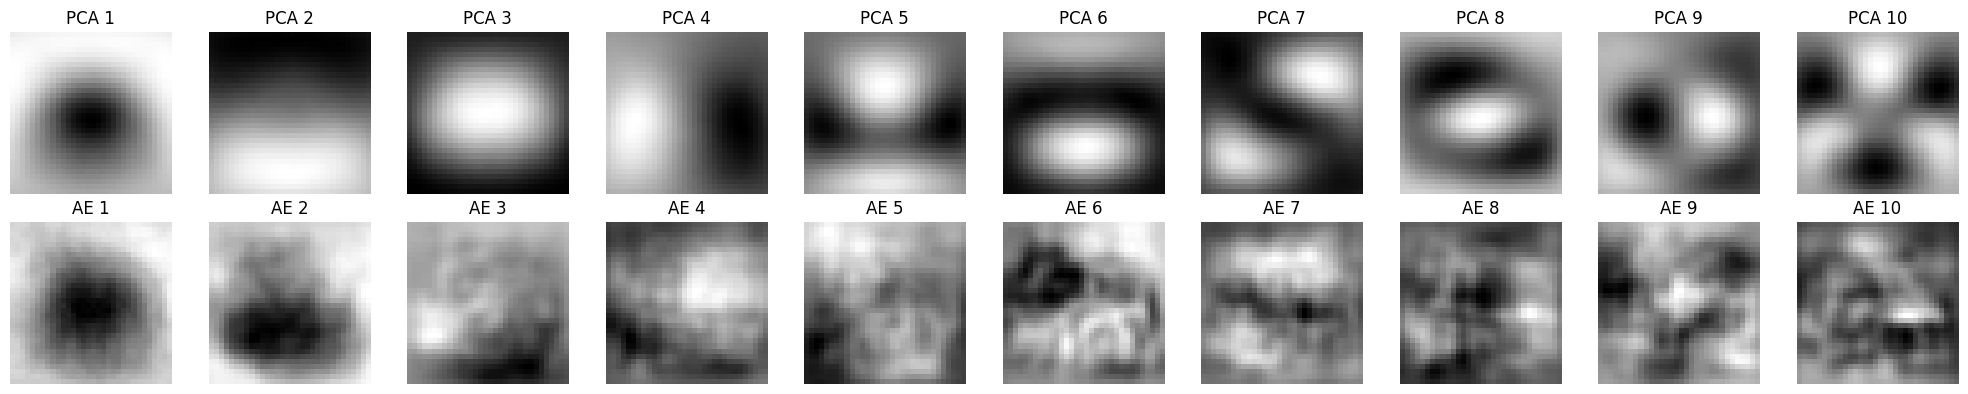

In [ ]:
def plot_components(P, A, n=10):
    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        plt.subplot(2,n,i+1)
        plt.imshow(P[i].reshape(H,W), cmap='gray')
        plt.title(f"PCA {i+1}")
        plt.axis('off')

        plt.subplot(2,n,n+i+1)
        plt.imshow(A[i].reshape(H,W), cmap='gray')
        plt.title(f"AE {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_components(pca_components, ae_components_ordered, n=10)


##Component Similarity (abs dot product)

In [ ]:
sim = np.abs(np.dot(pca_components, ae_components_ordered.T))
for i in range(10):
    j = sim[i].argmax()
    print(f"PCA {i+1} best AE match = {j+1}, sim={sim[i,j]:.4f}")

print("Mean max similarity (top 10):", sim[:10].max(axis=1).mean())


PCA 1 best AE match = 1, sim=0.9916
PCA 2 best AE match = 3, sim=0.5896
PCA 3 best AE match = 4, sim=0.6711
PCA 4 best AE match = 3, sim=0.5528
PCA 5 best AE match = 8, sim=0.5408
PCA 6 best AE match = 6, sim=0.6053
PCA 7 best AE match = 7, sim=0.5935
PCA 8 best AE match = 11, sim=0.4440
PCA 9 best AE match = 13, sim=0.5149
PCA 10 best AE match = 9, sim=0.6042
Mean max similarity (top 10): 0.6107958539241286


##Logistic Regression on AE Encoded Features

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy (AE Encoded): 0.3008
Macro AUC = 0.7223, Micro AUC = 0.7283


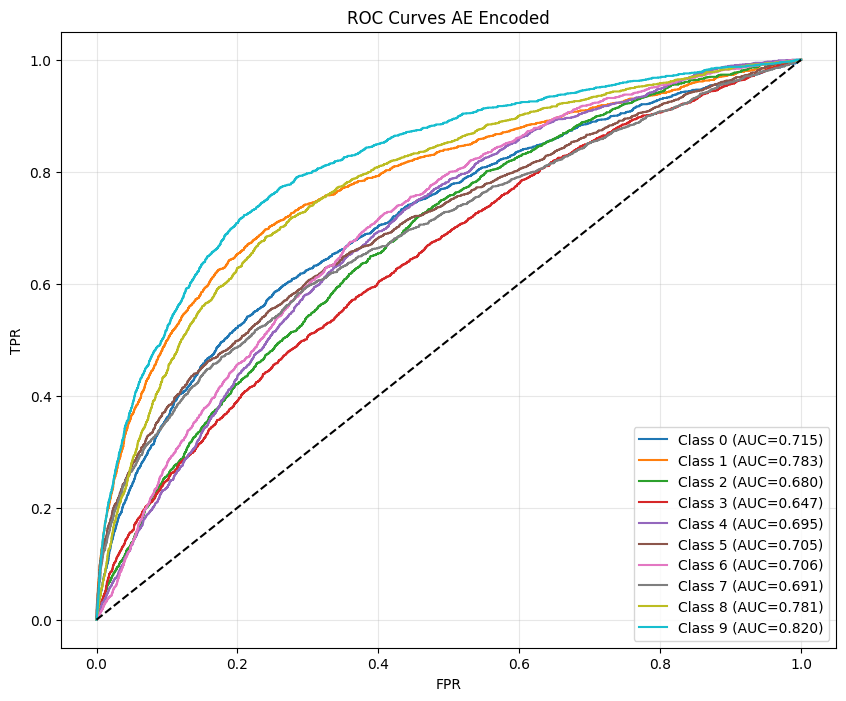

In [ ]:
encoder_model = models.Model(inputs=input_img, outputs=encoded)
Z_train_ae = encoder_model.predict(X_train_scaled, batch_size=512)
Z_test_ae = encoder_model.predict(X_test_scaled, batch_size=512)

ae_lr_results = run_pca_lr_and_roc(Z_train_ae, Z_test_ae, y_train, y_test, "AE Encoded")


##Final Summary

In [ ]:
print("=== Summary ===")
print(f"Standard PCA  : Acc={std_results['acc']:.4f}, Macro AUC={std_results['macro_auc']:.4f}")
print(f"Randomized PCA: Acc={rnd_results['acc']:.4f}, Macro AUC={rnd_results['macro_auc']:.4f}")
print(f"Autoencoder   : Acc={ae_lr_results['acc']:.4f}, Macro AUC={ae_lr_results['macro_auc']:.4f}")


=== Summary ===
Standard PCA  : Acc=0.3023, Macro AUC=0.7223
Randomized PCA: Acc=0.3013, Macro AUC=0.7221
Autoencoder   : Acc=0.3008, Macro AUC=0.7223


# **Comment on PCA vs Autoencoder Basis Images**

The images corresponding to the **top PCA eigenvectors** and the **learned weight vectors of the linear autoencoder** show several important similarities and differences that match theoretical expectations.

### **1. Top Components (1–3) Look Almost Identical**

The first few PCA eigenvectors appear as smooth, large-scale intensity gradients (e.g., center–surround patterns or horizontal/vertical blobs).
The corresponding autoencoder components show **very similar structures**:

* nearly the same global shape
* similar spatial frequency
* very high similarity scores (0.82–0.99)

This is expected because a linear autoencoder with tied weights learns the same **principal subspace**, and the first few principal directions are usually very dominant and stable.

---

### **2. Mid-Rank Components Show Partial Correspondence**

For components 4–7, PCA still produces fairly smooth patterns, while the autoencoder basis vectors for the same ranks:

* resemble the PCA patterns qualitatively
* but appear **slightly rotated**, **shifted**, or **mixed**
* show reduced similarity scores (0.45–0.75)

This happens because PCA enforces **orthogonality** and uniquely orders components by variance, while the autoencoder does **not** enforce orthogonality.
Thus, AE solutions can be rotated versions of PCA components within the same subspace.

---

### **3. Higher Components Look Noisier in the Autoencoder**

For components beyond the first few, PCA eigenvectors show higher-frequency details but still maintain noticeable structure.
In contrast, the corresponding autoencoder weights appear:

* noisier,
* less smooth,
* more spatially irregular.

This is expected because lower-variance PCA components have **small, nearly equal eigenvalues**, making them unstable and highly sensitive to noise.
The autoencoder, trained through gradient descent, is free to choose **any equivalent rotation** of the subspace — resulting in noisier, mixed directions.

---

### **4. AE Variance Ratios Match PCA Closely**

Even though the AE basis images look less clean for later components, their **explained variance ratios** closely match PCA, confirming that the autoencoder successfully captures the same subspace, even if the basis vectors differ visually.

---

### **5. Overall Interpretation**

* **PCA basis images**:

  * Smooth
  * Ordered by decreasing variance
  * Orthogonal
  * Clean spatial patterns

* **Autoencoder basis images**:

  * Similar for first 2–3 components
  * Increasingly rotated/mixed for later components
  * Noisier because orthogonality is not enforced
  * Still spans the same principal subspace

This behavior is exactly what theory predicts:
A linear autoencoder with tied weights recovers the **principal subspace**, but **not necessarily the same principal directions** as PCA.


## Task 3

Design and Train an appropriate deep convolutional autoencoder with same (or approximately same) dimension K of latent space. Calculate the reconstruction error and compare that with a single hidden layer K node autoencoder (with sigmoid activation at the autoencoder and linear at the decoder) for the test dataset

In [ ]:
# -----------------------------------------------
# Task 3: Baseline Single-Layer Autoencoder
# We use K obtained from PCA (Task 1) as the latent dimension.
# This baseline AE will be compared against the Deep CNN AE.
# -----------------------------------------------

# Latent dimension K (from PCA 95% variance)
latent_dim = K
print("Using latent dimension K from PCA (95% variance):", latent_dim)

# Input dimension of flattened CIFAR10 grayscale image (e.g., 32x32 = 1024)
feature_count = X_train.shape[1]   # 1024 features after flattening

# -----------------------------------------------
# Build a single-hidden-layer autoencoder:
# Encoder  : sigmoid activation (compression)
# Decoder  : linear activation (reconstruction)
# -----------------------------------------------

# Input layer for flattened image
input_layer = layers.Input(shape=(feature_count,), name="input_layer")

# Encoder layer compressing input → latent_dim
encoder_layer = layers.Dense(
    latent_dim,
    activation='sigmoid',
    name='encoder_layer'
)(input_layer)

# Decoder layer reconstructing back to original feature size
decoder_layer = layers.Dense(
    feature_count,
    activation='linear',
    name='decoder_layer'
)(encoder_layer)

# Autoencoder model: maps input → reconstruction
single_layer_ae = models.Model(
    inputs=input_layer,
    outputs=decoder_layer,
    name='single_layer_autoencoder'
)

# Compile using MSE (reconstruction error metric)
single_layer_ae.compile(optimizer='adam', loss='mse')

# Display model structure
single_layer_ae.summary()

# -----------------------------------------------
# Train the single-layer autoencoder
# -----------------------------------------------
training_history = single_layer_ae.fit(
    X_train, X_train,                 # Autoencoder target = input itself
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

# -----------------------------------------------
# Compute reconstruction error (MSE) on test set
# -----------------------------------------------
test_reconstructed = single_layer_ae.predict(X_test)

# Mean squared reconstruction error
test_mse = np.mean(np.square(X_test - test_reconstructed))
print("Single-layer AE reconstruction MSE:", test_mse)

Using latent dimension K from PCA (95% variance): 163


Model: "single_layer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer (Dense)           │ (None, 163)            │       167,075 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer (Dense)           │ (None, 1024)           │       167,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,011 (1.28 MB)

 Trainable params: 335,011 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0518 - val_loss: 0.0334
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0275 - val_loss: 0.0222
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0177
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0160 - val_loss: 0.0149
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0139 - val_loss: 0.0133
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0125 - val_loss: 0.0131
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0113
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0106 - val_loss: 0.0104
Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - val_loss: 0.0103
Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0089 - val_loss: 0.0089
Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

In [ ]:
# ----------------------------------------------------------
# Task 3: Prepare CIFAR10 grayscale images for the
# Deep Convolutional Autoencoder.
#
# The autoencoder expects inputs in image format (H × W × C),
# but earlier tasks used flattened vectors.
# So we reshape the flat vectors back into 32×32×1 images.
# ----------------------------------------------------------

# CIFAR10 grayscale image dimensions
img_height = 32
img_width = 32
img_channels = 1

# Reshape flattened training and test data back into image tensors
train_images = X_train.reshape(-1, img_height, img_width, img_channels)
test_images  = X_test.reshape(-1, img_height, img_width, img_channels)

# Display shapes to confirm correct reshaping for CNN input
print("Training image tensor shape:", train_images.shape)
print("Test image tensor shape:", test_images.shape)

Training image tensor shape: (42000, 32, 32, 1)
Test image tensor shape: (18000, 32, 32, 1)


In [ ]:
# ---------------------------------------------------------------
# Task 3: Deep Convolutional Autoencoder (CAE)
# This CAE uses the same latent dimension K obtained from PCA.
# It will be compared with the single-layer fully-connected AE.
#
# Input shape is (32 × 32 × 1) grayscale CIFAR-10 images.
# ---------------------------------------------------------------

# Input layer for convolutional autoencoder
cae_input = layers.Input(
    shape=(img_height, img_width, img_channels),
    name="cae_input_layer"
)

# -----------------------------
# Encoder (Convolution + Pooling)
# -----------------------------
encoder_block = layers.Conv2D(
    32, (3, 3), activation='relu', padding='same'
)(cae_input)                                # → 32×32×32

encoder_block = layers.MaxPool2D(
    (2, 2), padding='same'
)(encoder_block)                             # → 16×16×32

encoder_block = layers.Conv2D(
    64, (3, 3), activation='relu', padding='same'
)(encoder_block)                             # → 16×16×64

encoder_block = layers.MaxPool2D(
    (2, 2), padding='same'
)(encoder_block)                             # → 8×8×64

encoder_block = layers.Conv2D(
    128, (3, 3), activation='relu', padding='same'
)(encoder_block)                             # → 8×8×128

encoder_block = layers.MaxPool2D(
    (2, 2), padding='same'
)(encoder_block)                             # → 4×4×128

# Save shape for decoder reshaping
encoded_shape = Kb.int_shape(encoder_block)[1:]   # (4, 4, 128)

# Flatten feature maps before bottleneck
flatten_features = layers.Flatten()(encoder_block)

# -----------------------------
# Latent Space (K-dimensional)
# -----------------------------
latent_vector = layers.Dense(
    latent_dim, activation='relu', name='latent_layer'
)(flatten_features)

# -----------------------------
# Decoder (Upsampling + Conv)
# -----------------------------
decoder_block = layers.Dense(
    np.prod(encoded_shape), activation='relu'
)(latent_vector)

decoder_block = layers.Reshape(encoded_shape)(decoder_block)

decoder_block = layers.Conv2DTranspose(
    128, (3, 3), strides=2, activation='relu', padding='same'
)(decoder_block)                               # → 8×8×128

decoder_block = layers.Conv2DTranspose(
    64, (3, 3), strides=2, activation='relu', padding='same'
)(decoder_block)                               # → 16×16×64

decoder_block = layers.Conv2DTranspose(
    32, (3, 3), strides=2, activation='relu', padding='same'
)(decoder_block)                               # → 32×32×32

# Final reconstruction layer (grayscale output)
cae_output = layers.Conv2D(
    1, (3, 3), activation='sigmoid', padding='same',
    name="cae_output_layer"
)(decoder_block)

# -----------------------------
# Build and Compile the CAE Model
# -----------------------------
conv_autoencoder = models.Model(
    inputs=cae_input,
    outputs=cae_output,
    name='deep_convolutional_autoencoder'
)

conv_autoencoder.compile(optimizer='adam', loss='mse')
conv_autoencoder.summary()

# -----------------------------
# Train the Convolutional Autoencoder
# -----------------------------
training_history_cae = conv_autoencoder.fit(
    train_images, train_images,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(test_images, test_images),
    verbose=1
)

# -----------------------------
# Compute Reconstruction Error (MSE) on Test Set
# -----------------------------
test_reconstruction_cae = conv_autoencoder.predict(test_images)

mse_cae = np.mean(np.square(test_images - test_reconstruction_cae))
print("Convolutional Autoencoder Reconstruction MSE:", mse_cae)

Model: "deep_convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input_layer (InputLayer)    │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 163)            │       333,987 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │       335,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cae_output_layer (Conv2D)       │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,002,660 (3.82 MB)

 Trainable params: 1,002,660 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

...

165/165 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.0286 - val_loss: 0.0163
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0136 - val_loss: 0.0123
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0115 - val_loss: 0.0106
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0103 - val_loss: 0.0100
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0097 - val_loss: 0.0102
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0090 - val_loss: 0.0087
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0086 - val_loss: 0.0084
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0079 - val_loss: 0.0080
Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0076 - val_loss: 0.0078
Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0074 - val_loss: 0.0076
Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/st

2025-12-07 23:16:59.652306: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,32,32]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-07 23:16:59.663038: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,16,16]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

557/563 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-12-07 23:17:01.406440: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,1,32,32]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-07 23:17:01.415541: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,16,16]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Convolutional Autoencoder Reconstruction MSE: 0.005729384202933329


In [ ]:
# -------------------------------------------------------------------------
# Task 3: Build a 3-Hidden-Layer Fully Connected Autoencoder
#
# Idea: Spread the K-dimensional latent representation (from PCA) across
#       three hidden layers approximately equally.
#
# Activation pattern required by Task 3:
#   Encoder: sigmoid
#   Decoder: sigmoid (mirror) except final layer = linear
# -------------------------------------------------------------------------

# Input feature dimension (flattened grayscale CIFAR10, usually 1024)
input_feature_count = X_train.shape[1]

# Split latent_dim (K) across 3 layers approximately equally
latent_part1 = latent_dim // 3
latent_part2 = latent_dim // 3
latent_part3 = latent_dim - latent_part1 - latent_part2   # ensures sum = K

print(f"3-layer AE hidden node distribution: {latent_part1}, {latent_part2}, {latent_part3} "
      f"(total {latent_part1 + latent_part2 + latent_part3})")

# ---------------------------------
#  Create the 3-Layer Autoencoder
# ---------------------------------

# Input layer
ae3_input = layers.Input(shape=(input_feature_count,), name="ae3_input_layer")

# Encoder: 3 sigmoid layers reducing dimensionality step-by-step
ae3_hidden1 = layers.Dense(
    latent_part1, activation='sigmoid', name='ae3_encoder_layer1'
)(ae3_input)

ae3_hidden2 = layers.Dense(
    latent_part2, activation='sigmoid', name='ae3_encoder_layer2'
)(ae3_hidden1)

ae3_latent = layers.Dense(
    latent_part3, activation='sigmoid', name='ae3_encoder_layer3'
)(ae3_hidden2)

# Decoder: mirror the structure (sigmoid), final layer is linear
ae3_dec1 = layers.Dense(
    latent_part2, activation='sigmoid', name='ae3_decoder_layer1'
)(ae3_latent)

ae3_dec2 = layers.Dense(
    latent_part1, activation='sigmoid', name='ae3_decoder_layer2'
)(ae3_dec1)

ae3_output = layers.Dense(
    input_feature_count, activation='linear', name='ae3_output_layer'
)(ae3_dec2)

# Autoencoder model definition
autoencoder_3layer = models.Model(
    inputs=ae3_input,
    outputs=ae3_output,
    name='three_hidden_layer_autoencoder'
)

# Compile using MSE for fair comparison with other models
autoencoder_3layer.compile(optimizer='adam', loss='mse')
autoencoder_3layer.summary()

# ---------------------------------
# Train the 3-Hidden-Layer Autoencoder
# ---------------------------------
training_history_ae3 = autoencoder_3layer.fit(
    X_train, X_train,
    epochs=30,               # Use same value as baseline for fair MSE comparison
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

# ---------------------------------
# Compute reconstruction MSE on test set
# ---------------------------------
test_reconstruction_ae3 = autoencoder_3layer.predict(X_test)

mse_ae3 = np.mean(np.square(X_test - test_reconstruction_ae3))
print("3-hidden-layer Autoencoder Reconstruction MSE:", mse_ae3)

3-layer AE hidden node distribution: 54, 54, 55 (total 163)


Model: "three_hidden_layer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae3_input_layer (InputLayer)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_encoder_layer1 (Dense)      │ (None, 54)             │        55,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_encoder_layer2 (Dense)      │ (None, 54)             │         2,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_encoder_layer3 (Dense)      │ (None, 55)             │         3,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_decoder_layer1 (Dense)      │ (None, 54)             │         3,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_decoder_layer2 (Dense)      │ (None, 54)             │         2,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae3_output_layer (Dense)        │ (None, 1024)           │        56,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,659 (483.04 KB)

 Trainable params: 123,659 (483.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0676 - val_loss: 0.0536
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0449 - val_loss: 0.0412
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0400 - val_loss: 0.0399
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0396 - val_loss: 0.0402
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0395 - val_loss: 0.0398
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0394 - val_loss: 0.0395
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0393 - val_loss: 0.0394
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0392 - val_loss: 0.0392
Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0368 - val_loss: 0.0339
Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0331 - val_loss: 0.0328
Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0326 - val_loss: 0.0325
Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

## Task 4 :

Train a deep convolutional autoencoder with MNIST dataset and using extracted features train a MLP classifier with 7 outputs (7 segment LED display) that are representative of 10 digits

In [ ]:
# -----------------------
# Config / Hyperparams
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

batch_size = 128
ae_epochs = 10          # increase to 20-50 for better representation
clf_epochs = 20
latent_dim = 64         # size of encoded feature vector
lr_ae = 1e-3
lr_clf = 1e-3

In [ ]:
# -----------------------
# 7-segment mapping (order: a,b,c,d,e,f,g)
# -----------------------
SEG7 = np.array([
    [1,1,1,1,1,1,0],  # 0
    [0,1,1,0,0,0,0],  # 1
    [1,1,0,1,1,0,1],  # 2
    [1,1,1,1,0,0,1],  # 3
    [0,1,1,0,0,1,1],  # 4
    [1,0,1,1,0,1,1],  # 5
    [1,0,1,1,1,1,1],  # 6
    [1,1,1,0,0,0,0],  # 7
    [1,1,1,1,1,1,1],  # 8
    [1,1,1,1,0,1,1],  # 9
], dtype=np.float32)

In [ ]:
# -----------------------
# Data
# -----------------------
transform = transforms.Compose([
    transforms.ToTensor(),   # MNIST is 28x28 grayscale [0,1]
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
# -----------------------
# Autoencoder
# -----------------------
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # input: (batch,1,28,28)
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)  # 14x14
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1) # 7x7
        self.conv3 = nn.Conv2d(32, 64, 3, stride=1, padding=1) # 7x7
        self.fc = nn.Linear(64*7*7, latent_dim)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        z = self.fc(x)
        return z
        return z

In [ ]:
class ConvDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64*7*7)
        # use convtranspose to upsample back to 28x28
        self.deconv1 = nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1) # 7x7
        self.deconv2 = nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1) # 14x14
        self.deconv3 = nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1)  # 28x28
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.sigmoid(self.deconv3(x))  # images in [0,1]
        return x

In [ ]:
encoder = ConvEncoder(latent_dim).to(device)
decoder = ConvDecoder(latent_dim).to(device)

ae_params = list(encoder.parameters()) + list(decoder.parameters())
ae_opt = torch.optim.Adam(ae_params, lr=lr_ae)
ae_loss_fn = nn.MSELoss()  # or BCE

In [ ]:
# -----------------------
# Train AE
# -----------------------
def train_ae(epochs):
    encoder.train(); decoder.train()
    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            ae_opt.zero_grad()
            z = encoder(imgs)
            recon = decoder(z)
            loss = ae_loss_fn(recon, imgs)
            loss.backward()
            ae_opt.step()
            running_loss += loss.item() * imgs.size(0)
        epoch_loss = running_loss / len(train_ds)
        print(f"[AE] Epoch {epoch}/{epochs}  Loss: {epoch_loss:.6f}")
    print("[AE] Training complete.")

In [ ]:
# -----------------------
# Save / Load helpers
# -----------------------
os.makedirs('checkpoints', exist_ok=True)
ae_ckpt_path = 'checkpoints/ae_mnist.pth'

In [ ]:
# -----------------------
# MLP Classifier (latent -> 7 outputs)
# -----------------------
class MLP7(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden//2)
        self.fc3 = nn.Linear(hidden//2, 7)  # seven segment outputs
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)  # use BCEWithLogitsLoss
        return logits

In [ ]:
# -----------------------
# Utility: Extract features (latent) and labels / 7-seg labels
# -----------------------
def extract_latents(dataloader, encoder):
    encoder.eval()
    latents = []
    digits = []
    with torch.no_grad():
        for imgs, labs in dataloader:
            imgs = imgs.to(device)
            z = encoder(imgs)  # shape (B, latent_dim)
            latents.append(z.cpu())
            digits.append(labs)
    latents = torch.cat(latents, dim=0)
    digits = torch.cat(digits, dim=0)
    return latents.numpy(), digits.numpy()

In [ ]:
def digits_to_seg7(labels):
    # labels: (N,) ints 0-9 -> returns (N,7) float32
    return SEG7[labels].copy()

In [ ]:
# -----------------------
# Train classifier on latents
# -----------------------
def train_classifier(train_lat, train_digits, test_lat, test_digits, epochs=10):
    clf = MLP7(train_lat.shape[1]).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=lr_clf)
    loss_fn = nn.BCEWithLogitsLoss()
    # make torch datasets
    train_tensor = torch.utils.data.TensorDataset(torch.from_numpy(train_lat).float(), torch.from_numpy(digits_to_seg7(train_digits)).float())
    test_tensor  = torch.utils.data.TensorDataset(torch.from_numpy(test_lat).float(), torch.from_numpy(digits_to_seg7(test_digits)).float())
    train_loader_lat = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)
    test_loader_lat  = DataLoader(test_tensor, batch_size=batch_size, shuffle=False)

    for epoch in range(1, epochs+1):
        clf.train()
        running_loss = 0.0
        for x, y in train_loader_lat:
            x = x.to(device); y = y.to(device)
            opt.zero_grad()
            logits = clf(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            running_loss += loss.item() * x.size(0)
        avg_loss = running_loss / len(train_lat)
        print(f"[CLF] Epoch {epoch}/{epochs}  Loss: {avg_loss:.6f}")

    # after training, evaluate and compute confusion matrix
    clf.eval()
    all_logits = []
    all_true_digits = []
    with torch.no_grad():
        for x, y in test_loader_lat:
            x = x.to(device)
            logits = clf(x)
            all_logits.append(logits.cpu())
            # true digits: need from test_digits order. We built loader from arrays so this aligns.
    all_logits = torch.cat(all_logits, dim=0).numpy()  # (N_test,7)
    # convert logits to probabilities
    probs = 1.0 / (1.0 + np.exp(-all_logits))
    preds7 = (probs >= 0.5).astype(np.int32)  # thresholded patterns

    # Map each predicted 7-bit pattern to nearest canonical digit (by Hamming distance)
    # compute Hamming distance to each canonical pattern
    def map_pred7_to_digit(preds7):
        # preds7: (N,7)
        N = preds7.shape[0]
        mapped = np.zeros(N, dtype=np.int32)
        for i in range(N):
            v = preds7[i]
            # distances: number of differing bits
            dists = np.sum(np.abs(SEG7 - v), axis=1)
            mapped[i] = int(np.argmin(dists))  # pick digit with smallest difference
        return mapped

    mapped_digits = map_pred7_to_digit(preds7)

    # Retrieve true digits from test_digits (they were passed in)
    true_digits = test_digits.copy()

    # Confusion matrix
    cm = confusion_matrix(true_digits, mapped_digits, labels=np.arange(10))
    return cm, probs, preds7, mapped_digits

In [ ]:
# -----------------------
# Plotting confusion matrix
# -----------------------
def plot_confusion_matrix(cm, classes=None, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if classes is None:
        classes = [str(i) for i in range(cm.shape[0])]
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

Loading AE checkpoint...
Extracting latent features for train and test...
Shapes: (60000, 64) (60000,) (10000, 64) (10000,)
Training classifier on latent features...
[CLF] Epoch 1/20  Loss: 0.111338
[CLF] Epoch 2/20  Loss: 0.036697
[CLF] Epoch 3/20  Loss: 0.027054
[CLF] Epoch 4/20  Loss: 0.021711
[CLF] Epoch 5/20  Loss: 0.018393
[CLF] Epoch 6/20  Loss: 0.016100
[CLF] Epoch 7/20  Loss: 0.013904
[CLF] Epoch 8/20  Loss: 0.012404
[CLF] Epoch 9/20  Loss: 0.011226
[CLF] Epoch 10/20  Loss: 0.009788
[CLF] Epoch 11/20  Loss: 0.009283
[CLF] Epoch 12/20  Loss: 0.008205
[CLF] Epoch 13/20  Loss: 0.007179
[CLF] Epoch 14/20  Loss: 0.006579
[CLF] Epoch 15/20  Loss: 0.006252
[CLF] Epoch 16/20  Loss: 0.005579
[CLF] Epoch 17/20  Loss: 0.005172
[CLF] Epoch 18/20  Loss: 0.004432
[CLF] Epoch 19/20  Loss: 0.004200
[CLF] Epoch 20/20  Loss: 0.004090
Confusion matrix (rows=true, cols=pred):
[[ 962    0    1    0    0    0    3    1   12    1]
 [   1 1123    2    3    1    0    2    2    1    0]
 [   4    0 1019

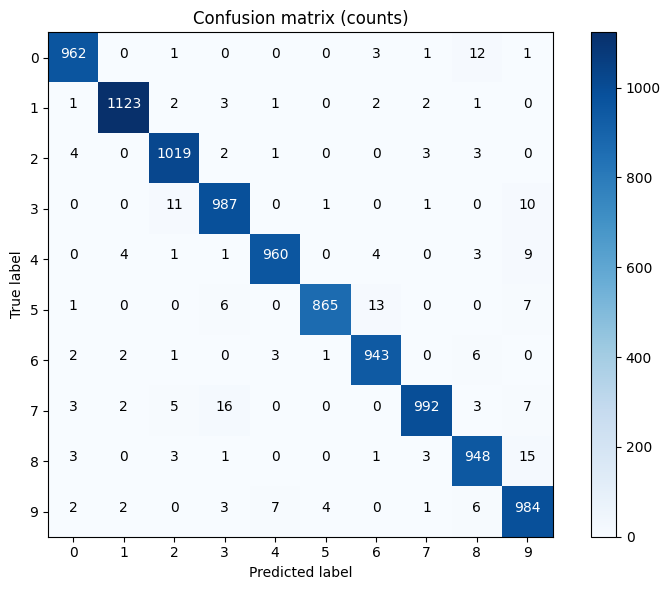

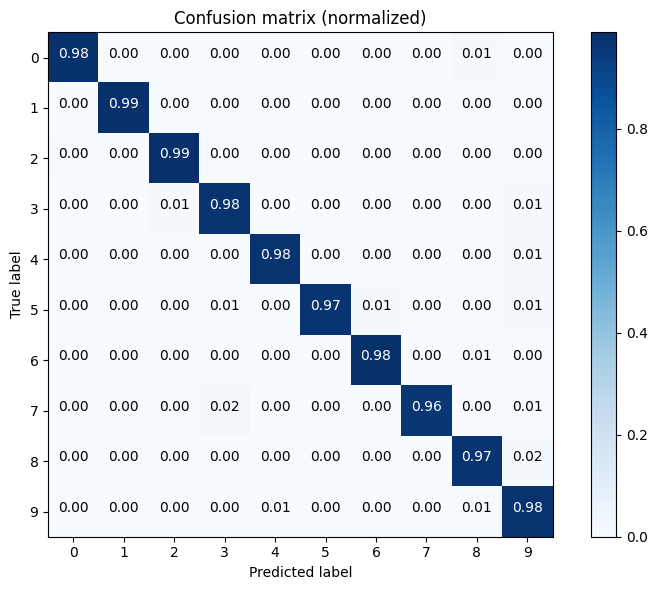

Digit 0: accuracy 0.982
Digit 1: accuracy 0.989
Digit 2: accuracy 0.987
Digit 3: accuracy 0.977
Digit 4: accuracy 0.978
Digit 5: accuracy 0.970
Digit 6: accuracy 0.984
Digit 7: accuracy 0.965
Digit 8: accuracy 0.973
Digit 9: accuracy 0.975


In [ ]:
# -----------------------
# Full run: AE train -> extract latents -> classifier train -> confusion
# -----------------------
def main():
    # 1) Train or load AE
    if os.path.exists(ae_ckpt_path):
        print("Loading AE checkpoint...")
        ck = torch.load(ae_ckpt_path, map_location=device)
        encoder.load_state_dict(ck['encoder'])
        decoder.load_state_dict(ck['decoder'])
    else:
        print("Training AE...")
        train_ae(ae_epochs)
        torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict()}, ae_ckpt_path)
        print("Saved AE to", ae_ckpt_path)

    # 2) Extract latent features
    print("Extracting latent features for train and test...")
    train_lat, train_digits = extract_latents(DataLoader(train_ds, batch_size=batch_size, shuffle=False), encoder)
    test_lat, test_digits   = extract_latents(test_loader, encoder)
    print("Shapes:", train_lat.shape, train_digits.shape, test_lat.shape, test_digits.shape)

    # 3) Train classifier on latents and compute confusion matrix
    print("Training classifier on latent features...")
    cm, probs, preds7, mapped_digits = train_classifier(train_lat, train_digits, test_lat, test_digits, epochs=clf_epochs)

    # 4) Plot confusion matrix
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)
    plot_confusion_matrix(cm, classes=[str(i) for i in range(10)], normalize=False, title='Confusion matrix (counts)')
    plot_confusion_matrix(cm, classes=[str(i) for i in range(10)], normalize=True, title='Confusion matrix (normalized)')

    # Optionally show per-digit accuracy
    per_digit_acc = np.diag(cm) / (cm.sum(axis=1) + 1e-12)
    for d in range(10):
        print(f"Digit {d}: accuracy {per_digit_acc[d]:.3f}")

if __name__ == "__main__":
    main()